In [1]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling (1).csv to Churn_Modelling (1).csv


In [4]:
import pandas as pd
df = pd.read_csv("Churn_Modelling (1).csv")

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
print(df.shape)
df.info()
df.describe()

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [9]:
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


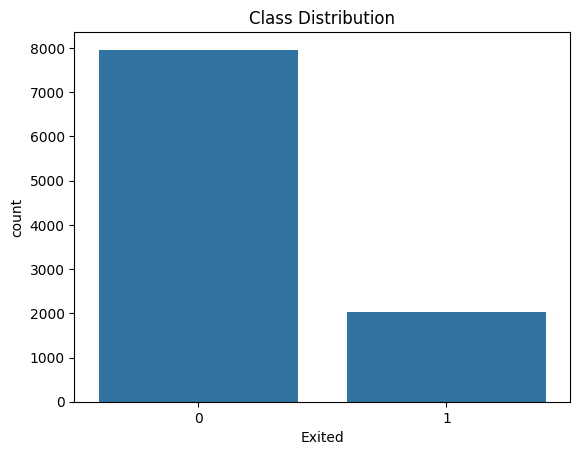

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [10]:
sns.countplot(x='Exited', data=df)
plt.title("Class Distribution")
plt.show()

print(df['Exited'].value_counts(normalize=True))

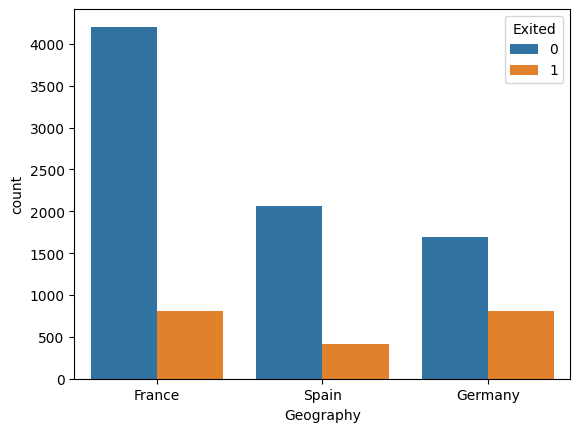

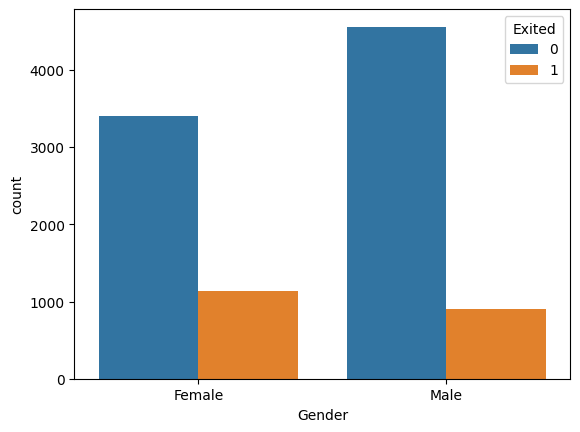

In [11]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()

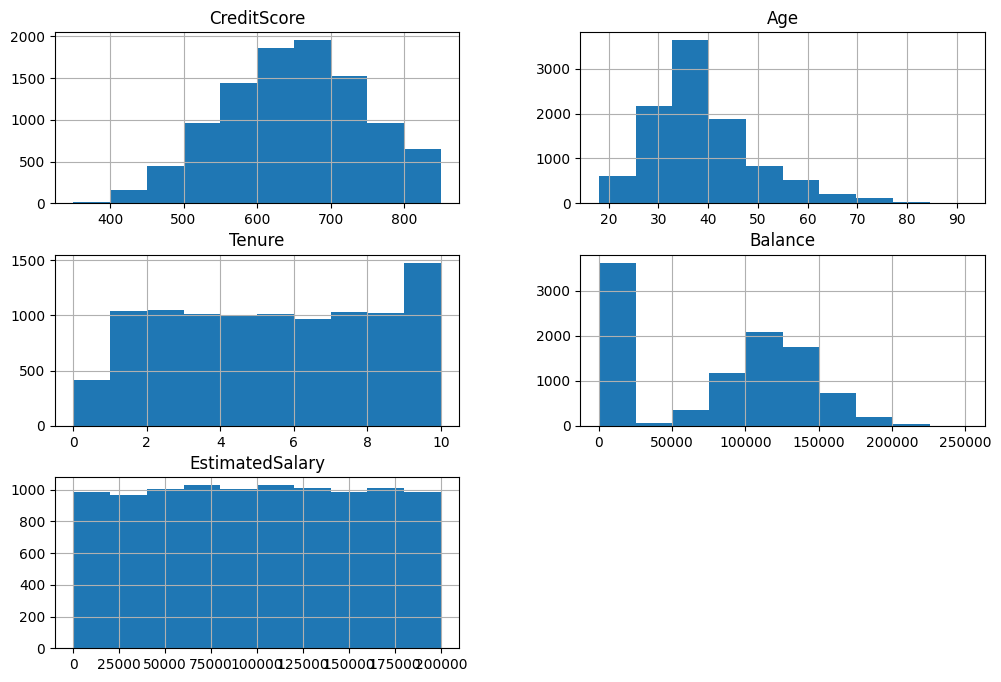

In [12]:
num_cols = ['CreditScore','Age','Tenure','Balance','EstimatedSalary']

df[num_cols].hist(figsize=(12,8))
plt.show()

In [14]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

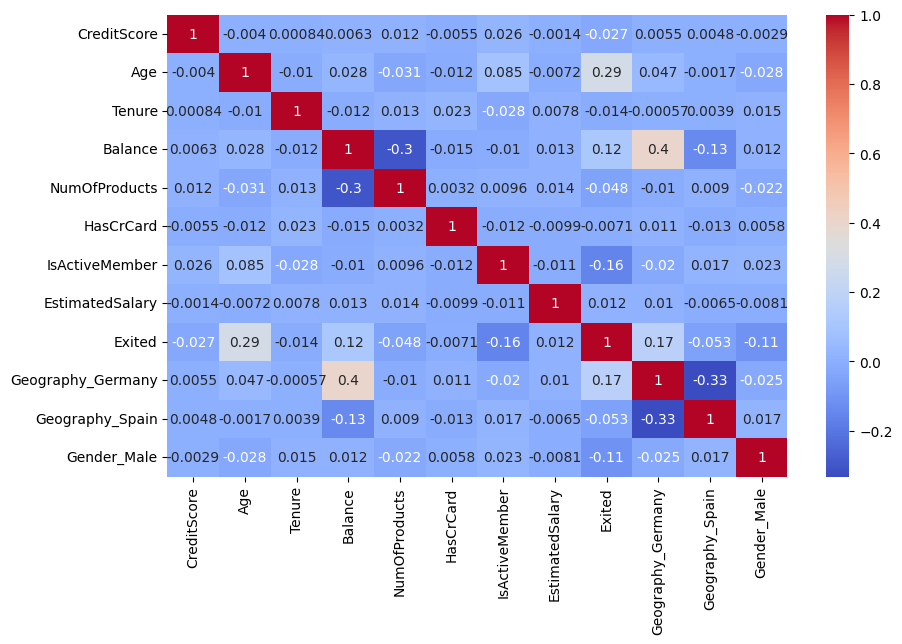

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [16]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))

Before SMOTE: [6370 1630]
After SMOTE: [6370 6370]


In [19]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}


In [20]:
results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

    roc = roc_auc_score(y_test, y_prob)
    print("ROC-AUC:", roc)

    results[name] = roc


Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000

ROC-AUC: 0.7768754887398955

Decision Tree
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1593
           1       0.44      0.51      0.47       407

    accuracy                           0.77      2000
   macro avg       0.65      0.67      0.66      2000
weighted avg       0.78      0.77      0.77      2000

ROC-AUC: 0.6702087295307635

Random Forest
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.60      0.59      0.60       407

    accuracy                           0.84      2000
   macro avg       0.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:48:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.66      0.56      0.61       407

    accuracy                           0.85      2000
   macro avg       0.78      0.74      0.76      2000
weighted avg       0.84      0.85      0.85      2000

ROC-AUC: 0.8380213803942619


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:49:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


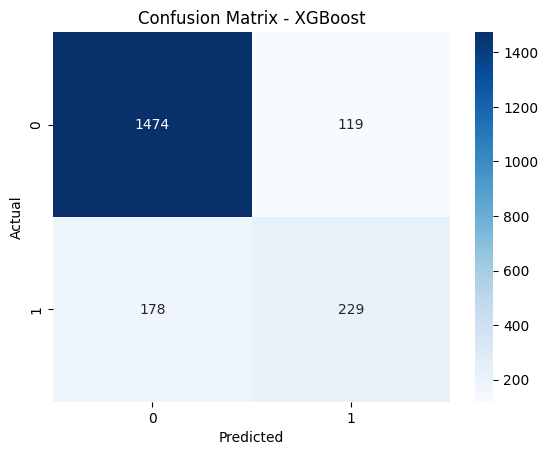

In [21]:
best_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
best_model.fit(X_train_res, y_train_res)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

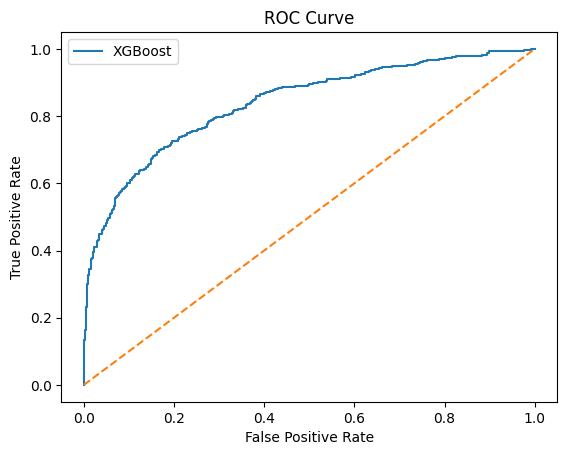

In [22]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

scores = cross_val_score(xgb, X_train_res, y_train_res, cv=cv, scoring='roc_auc')

print("Cross-Validation ROC-AUC:", scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:49:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:49:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:49:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:49:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Cross-Validation ROC-AUC: 0.9604239111415609


In [24]:
!pip install streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 39.8 MB/s eta 0:00:00
--2026-05-01 16:54:51--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb [following]
--2026-05-01 16:54:51--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/ec689fe1-d727-4ebd-bbc3-5967730ab54e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-01T17%3A32%3A39Z&rscd=attachment%3B+f

In [25]:
import joblib

joblib.dump(best_model, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [26]:
%%writefile app.py

import streamlit as st
import numpy as np
import joblib

# Load model
model = joblib.load("xgb_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Customer Churn Prediction App")

st.write("Enter customer details:")

# Inputs
credit_score = st.number_input("Credit Score", 300, 900)
age = st.number_input("Age", 18, 100)
tenure = st.number_input("Tenure", 0, 10)
balance = st.number_input("Balance", 0.0)
num_products = st.number_input("Number of Products", 1, 4)
has_cr_card = st.selectbox("Has Credit Card", [0,1])
is_active = st.selectbox("Is Active Member", [0,1])
salary = st.number_input("Estimated Salary", 0.0)

geography = st.selectbox("Geography", ["Germany", "Spain", "France"])
gender = st.selectbox("Gender", ["Male", "Female"])

# Encoding
geo_germany = 1 if geography == "Germany" else 0
geo_spain = 1 if geography == "Spain" else 0
gender_male = 1 if gender == "Male" else 0

# Prediction
if st.button("Predict"):

    input_data = np.array([[credit_score, age, tenure, balance,
                            num_products, has_cr_card, is_active, salary,
                            geo_germany, geo_spain, gender_male]])

    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    if prediction == 1:
        st.error(f"Customer is likely to CHURN (Probability: {probability:.2f})")
    else:
        st.success(f"Customer is likely to STAY (Probability: {probability:.2f})")

Writing app.py


In [27]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-05-01T16:55:45Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-01T16:55:45Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-01T16:55:48Z INF +--------------------------------------------------------------------------------------------+
2026-05-01T16:55:48Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-01T16:55:48Z INF |  https://array-reference-procurement-apart.trycloudfla